In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import missingno as msno
import joblib

# Establish Country & Pollutant

In [2]:
load_dotenv()

True

In [3]:
POLLUTANT = "NOXasNO2"

In [4]:
COUNTRY_CODE = os.getenv("COUNTRY_CODE")  
RESULTS_SAVE_FOLDER = os.getenv("RESULTS_SAVE_FOLDER")

In [5]:
RUN_ID = f"{COUNTRY_CODE}_{POLLUTANT}"

output_dir = Path(RESULTS_SAVE_FOLDER) / f"Results_{RUN_ID}"
output_dir.mkdir(parents=True, exist_ok=True)

In [6]:
def log_stat(name, value): # save statistics as a test file
    with open(output_dir / "data_processing_log.txt", "a") as f:
        f.write(f"{name}: {value}\n")

with open(output_dir / "data_processing_log.txt", "w") as f: # clear log if it exists to start fresh
    f.write(f"Processing Log for {RUN_ID}\n")

# Load Data

In [7]:
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [8]:
table_name = f"air_quality_{COUNTRY_CODE}"

In [9]:
query = f"""
SELECT * FROM {table_name} 
WHERE "Pollutant" = 9;
"""

df= pd.read_sql_query(query, engine)

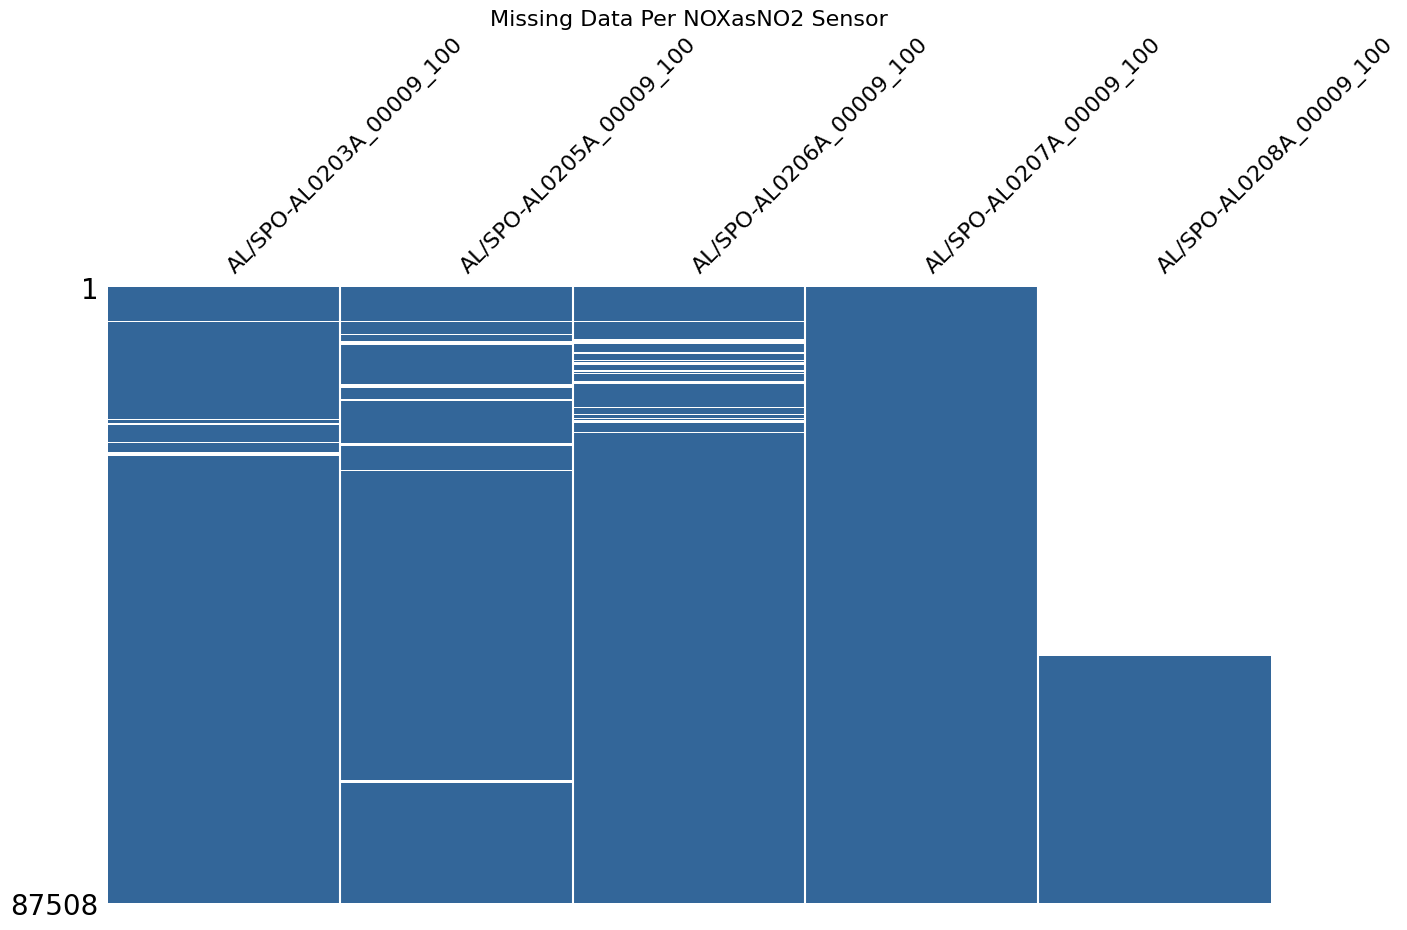

Longest continuous NaN streaks per NOXasNO2 Station:
Samplingpoint
AL/SPO-AL0203A_00009_100    0
AL/SPO-AL0205A_00009_100    0
AL/SPO-AL0206A_00009_100    0
AL/SPO-AL0207A_00009_100    0
AL/SPO-AL0208A_00009_100    0
Name: Value, dtype: int64


In [10]:
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

df_pivot = df.pivot_table(index='Start', columns='Samplingpoint', values='Value') # pivot the data to get a matrix of sampling points vs time, with the values being the pollutant measurements.

# Visualize the missing data gaps per sensor with msno matrix to show presence and absence of data
msno.matrix(df_pivot, figsize=(15, 8), color=(0.2, 0.4, 0.6), sparkline=False)
plt.title(f"Missing Data Per {POLLUTANT} Sensor", fontsize=16)
plt.savefig(output_dir / f"{RUN_ID}_msno_matrix.png", bbox_inches='tight')
plt.show()
plt.close()
# longest streak of missing data
def max_consecutive_nans(series):
    is_na = series.isna()
    # Cumulatively (cumsum) sum the non-NaNs to create unique group IDs for consecutive NaNs
    return is_na.groupby((~is_na).cumsum()).sum().max()

longest_nan_streaks = df.groupby('Samplingpoint')['Value'].apply(max_consecutive_nans) 
longest_nan_streaks = longest_nan_streaks.sort_values(ascending=False)

print(f"Longest continuous NaN streaks per {POLLUTANT} Station:")
print(longest_nan_streaks.head(10))

In [11]:
log_stat("Longest continuous NaN streaks per Station", longest_nan_streaks)

In [12]:
df['Start'] = pd.to_datetime(df['Start'])

In [13]:
print(f"Rows in dataset: {len(df)}")
print(f"NaN rows in dataset: {df['Value'].isna().sum()}")
print(f"Non-NaN rows in dataset: {df['Value'].notna().sum()}")
df.head()

Rows in dataset: 377698
NaN rows in dataset: 0
Non-NaN rows in dataset: 377698


,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture
0,AL/SPO-AL0203A_00009_100,9,2015-01-01 00:00:00,2015-01-01 01:00:00,6.73506,ug.m-3,hour,1,1,2017-01-24 15:50:29,None
1,AL/SPO-AL0203A_00009_100,9,2015-01-01 01:00:00,2015-01-01 02:00:00,4.85775,ug.m-3,hour,1,1,2017-01-24 15:50:29,None
2,AL/SPO-AL0203A_00009_100,9,2015-01-01 02:00:00,2015-01-01 03:00:00,4.84398,ug.m-3,hour,1,1,2017-01-24 15:50:29,None
3,AL/SPO-AL0203A_00009_100,9,2015-01-01 03:00:00,2015-01-01 04:00:00,5.97006,ug.m-3,hour,1,1,2017-01-24 15:50:29,None
4,AL/SPO-AL0203A_00009_100,9,2015-01-01 04:00:00,2015-01-01 05:00:00,5.77575,ug.m-3,hour,1,1,2017-01-24 15:50:29,None


In [14]:
log_stat("Original Rows", len(df))
log_stat(f"Original NaN rows in dataset: ", df['Value'].isna().sum())
log_stat(f"Original Non-NaN rows in dataset: ", df['Value'].notna().sum())

# Clean Data & Fill gaps when it makes sense to do so

In [15]:
df.loc[(df['Value'] < 0) | (df['Validity'] == -1), 'Value'] = np.nan # Set all invalid and impossible values to NaN

print(f"Total NaN readings after removing data collection errors: {df['Value'].isna().sum()}")

Total NaN readings after removing data collection errors: 194127


In [16]:
log_stat(f"Total NaN readings after removing data collection errors( -1 validity or value < 0): ", df['Value'].isna().sum())

In [17]:
df_unified = df.copy() # due to using samplingpoint (previosuly split it up into staionid and sample) this si to work with my code.

In [18]:
def apply_hourly_interpolation(group): # Time-weighted linear interpolation with a 3 hour limit
    
    # Enforce a continuous hourly timeline, required for time-based interpolation
    group = group.set_index('Start').resample('h').asfreq()# asfreq() creates new rows for missing hours with NaN values
    
    group['Value'] = group['Value'].interpolate(method='time', limit=3) 
    
    # Return ONLY the Value column Pandas will automatically re-attach the Samplingpoint
    return group[['Value']]

In [19]:
# Apply interpolation
df_hourly = df_unified.groupby('Samplingpoint').apply(apply_hourly_interpolation).reset_index()

print(f"Hourly dataset size after resampling and patching: {len(df_hourly)}") # may have more rows due to .resample('h').asfreq() filling in missing hours with NaNs
print(f"Remaining NaNs to handle later: {df_hourly['Value'].isna().sum()}")
df_hourly.head(10)

Hourly dataset size after resampling and patching: 385632
Remaining NaNs to handle later: 198654


,Samplingpoint,Start,Value
0,AL/SPO-AL0203A_00009_100,2015-01-01 00:00:00,6.73506
1,AL/SPO-AL0203A_00009_100,2015-01-01 01:00:00,4.85775
2,AL/SPO-AL0203A_00009_100,2015-01-01 02:00:00,4.84398
3,AL/SPO-AL0203A_00009_100,2015-01-01 03:00:00,5.97006
4,AL/SPO-AL0203A_00009_100,2015-01-01 04:00:00,5.77575
5,AL/SPO-AL0203A_00009_100,2015-01-01 05:00:00,6.94773
6,AL/SPO-AL0203A_00009_100,2015-01-01 06:00:00,3.74697
7,AL/SPO-AL0203A_00009_100,2015-01-01 07:00:00,4.38345
8,AL/SPO-AL0203A_00009_100,2015-01-01 08:00:00,6.39540
9,AL/SPO-AL0203A_00009_100,2015-01-01 09:00:00,7.78158


In [20]:
log_stat(f"Hourly dataset size after resampling and interpolation: ", len(df_hourly))
log_stat(f"Remaining NaNs to handle later: ", df_hourly['Value'].isna().sum())

# Aggregation & Fill in gaps when possible

In [21]:
def aggregate_to_daily(station_group): # Houly to daily aggregation with a minimum 75% of valid data (18 hour)

    station_group = station_group.set_index('Start') # Temp index for resampling
    
    # Resample to daily, calculate mean and the count of valid hours
    daily_stats = station_group['Value'].resample('D').agg(
        Daily_Value='mean', 
        Valid_Hours='count'
    )
    
    # if less than 18 hours valid set daily to NaN
    daily_stats.loc[daily_stats['Valid_Hours'] < 18, 'Daily_Value'] = np.nan
    
    # Drop the Valid_Hours column and rename back to 'Value'
    return daily_stats[['Daily_Value']].rename(columns={'Daily_Value': 'Value'})

In [22]:
# Apply agg per station
df_daily = df_hourly.groupby('Samplingpoint').apply(aggregate_to_daily).reset_index()

print(f"Aggregated to {len(df_daily)} daily rows.")
print(f"Days that are NaN including days with less than 75% data: {df_daily['Value'].isna().sum()}")
df_daily.head()

Aggregated to 16068 daily rows.
Days that are NaN including days with less than 75% data: 8362


,Samplingpoint,Start,Value
0,AL/SPO-AL0203A_00009_100,2015-01-01,22.259779
1,AL/SPO-AL0203A_00009_100,2015-01-02,42.292770
2,AL/SPO-AL0203A_00009_100,2015-01-03,54.644078
3,AL/SPO-AL0203A_00009_100,2015-01-04,26.254864
4,AL/SPO-AL0203A_00009_100,2015-01-05,16.319299


In [23]:
log_stat(f"Aggregated to daily rows totalling: ", len(df_daily))
log_stat(f"Days that are NaN including days with less than 75% data: ", df_daily['Value'].isna().sum())

In [24]:
# Daily Time weighted linear interpolation, 2 missing days max
def apply_daily_interpolation(station_group):
    station_group = station_group.set_index('Start') # Make Datetime index again for Pd

    station_group['Value'] = station_group['Value'].interpolate(method='time', limit=2)
    return station_group[['Value']]

In [25]:
# Apply the interpolation per station
df_daily_Final = df_daily.groupby('Samplingpoint').apply(apply_daily_interpolation).reset_index()

print(f"Dataset size after coverting to daily and interpolation: {len(df_daily_Final)}")
print(f"Remaining persistent NaNs with gaps for than 2 days: {df_daily_Final['Value'].isna().sum()}")
df_daily_Final.head()

Dataset size after coverting to daily and interpolation: 16068
Remaining persistent NaNs with gaps for than 2 days: 8066


,Samplingpoint,Start,Value
0,AL/SPO-AL0203A_00009_100,2015-01-01,22.259779
1,AL/SPO-AL0203A_00009_100,2015-01-02,42.292770
2,AL/SPO-AL0203A_00009_100,2015-01-03,54.644078
3,AL/SPO-AL0203A_00009_100,2015-01-04,26.254864
4,AL/SPO-AL0203A_00009_100,2015-01-05,16.319299


In [26]:
log_stat(f"Dataset size after coverting to daily and interpolation: ", len(df_daily_Final))
log_stat(f"Remaining persistent NaNs with gaps for than 2 days: ", df_daily_Final['Value'].isna().sum())


# Saving Cleaned Data

In [27]:
target_folder = os.getenv("BASE_DATA_PATH") # target folder saved in .env

# Dynamically naming country and polulutant for auto name and save
file_name = f"{COUNTRY_CODE}_{POLLUTANT}_Daily_Cleaned.parquet"
file_path = os.path.join(target_folder, file_name)

df_daily_Final.to_parquet(file_path, index=False) # save cleaned data as parquet

# Before, During & After Plotted

In [28]:
print("Before Interpolation hourly (df_unified)")
print(f"Total NaNs: {df_unified['Value'].isna().sum()}")
print(df_unified['Value'].describe())

print("\nAfter Interpolation hourly (df_dhourly)")
print(f"Total NaNs: {df_hourly['Value'].isna().sum()}")
print(df_hourly['Value'].describe())

Before Interpolation hourly (df_unified)
Total NaNs: 194127
count    183571.000000
mean         27.911977
std         135.813723
min           0.000000
25%           5.805225
50%          15.714800
75%          38.915050
max       40545.000000
Name: Value, dtype: float64

After Interpolation hourly (df_dhourly)
Total NaNs: 198654
count    186978.000000
mean         28.066536
std         134.664582
min           0.000000
25%           5.888100
50%          15.865950
75%          39.134255
max       40545.000000
Name: Value, dtype: float64


In [29]:
log_stat(f"Total Hourly NaNs Before Interpolation: ", df_unified['Value'].isna().sum())
log_stat(f"Total Hourly NaNs After Interpolation: ", df_hourly['Value'].isna().sum())

In [30]:
print("Before Interpolation (df_daily)")
print(f"Total NaNs: {df_daily['Value'].isna().sum()}")
print(df_daily['Value'].describe())

print("\nAfter Interpolaton (df_daily_Final)")
print(f"Total NaNs: {df_daily_Final['Value'].isna().sum()}")
print(df_daily_Final['Value'].describe())

Before Interpolation (df_daily)
Total NaNs: 8362
count    7706.000000
mean       27.992515
std        36.759770
min         0.000000
25%         8.976629
50%        22.265320
75%        40.584939
max      1744.203537
Name: Value, dtype: float64

After Interpolaton (df_daily_Final)
Total NaNs: 8066
count    8002.000000
mean       28.179992
std        36.408207
min         0.000000
25%         9.109877
50%        22.518241
75%        40.880245
max      1744.203537
Name: Value, dtype: float64


In [31]:
log_stat(f"Total NaNs Before Interpolation (df_daily): ", df_daily['Value'].isna().sum())

log_stat(f"Total NaNs After Interpolaton (df_daily_Final): ", df_daily_Final['Value'].isna().sum())

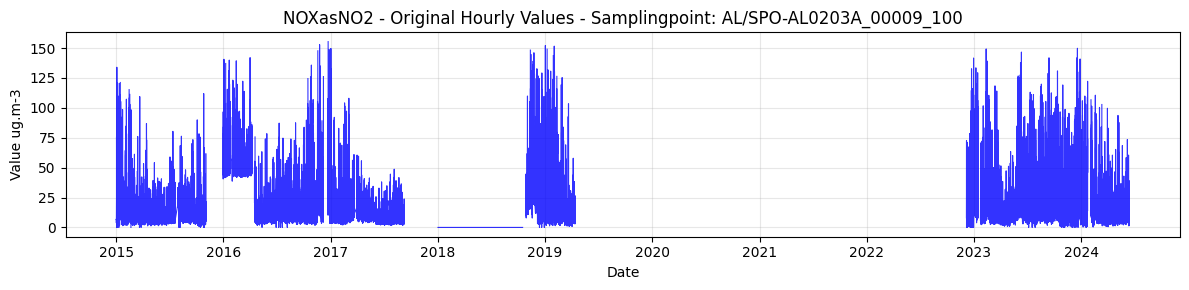

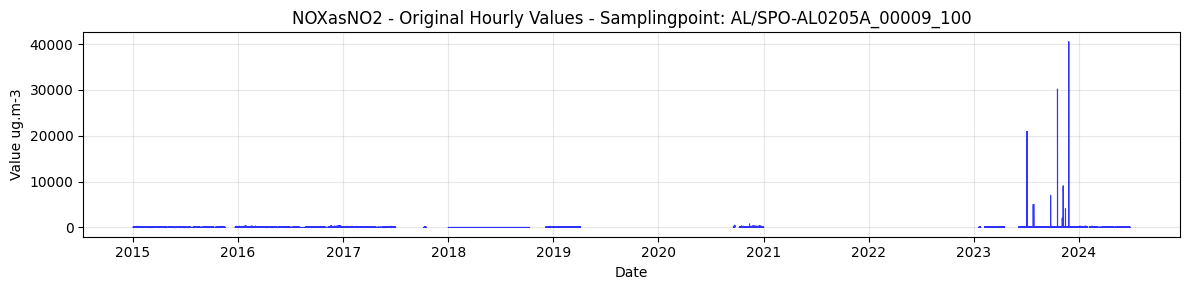

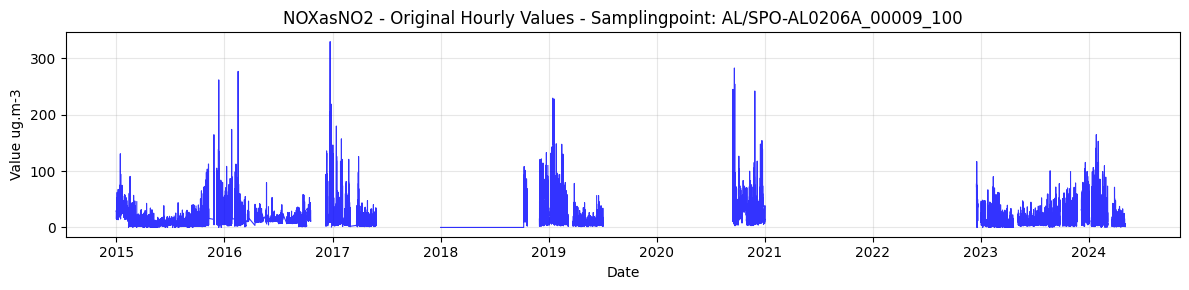

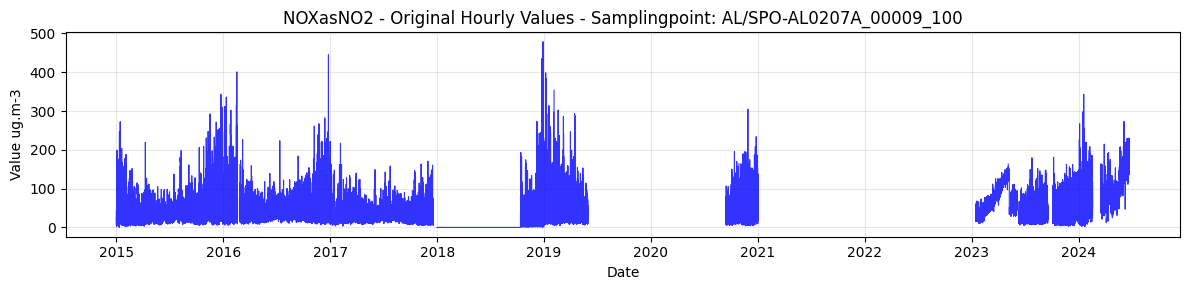

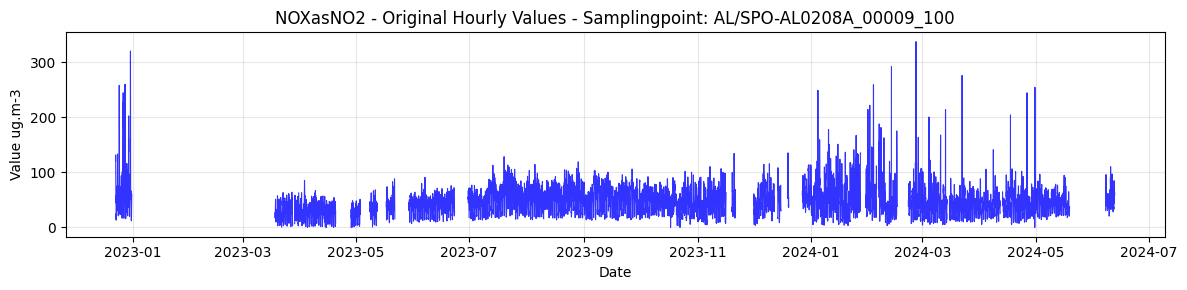

In [32]:
#Create a specific folder for these plots so they don't clutter your main directory
plot_dir = output_dir / "Original_Hourly_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_unified['Samplingpoint'].unique()

for station in stations:
    station_data = df_unified[df_unified['Samplingpoint'] == station]
    
   
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='blue', alpha=0.8, linewidth=0.8)

    plt.title(f'{POLLUTANT} - Original Hourly Values - Samplingpoint: {station}')
    plt.ylabel('Value ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Dynamic save for each plot in the loop
    # We clean the station name (replace dots/slashes with underscores) to avoid file errors
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_hourly.png"
    
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    
    plt.show() 
    plt.close() 

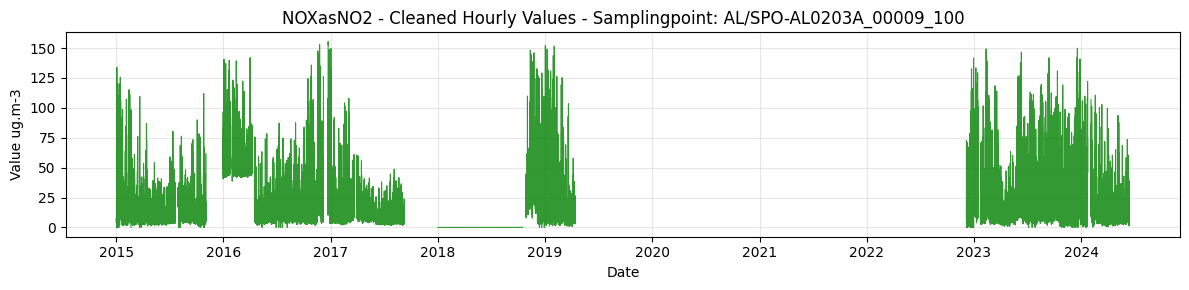

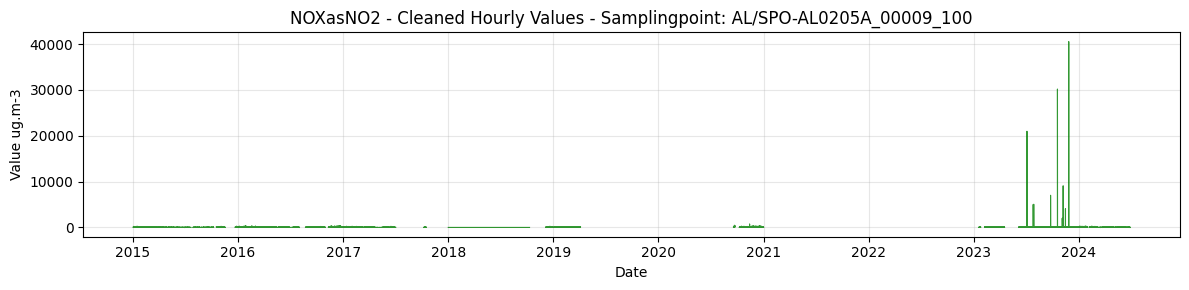

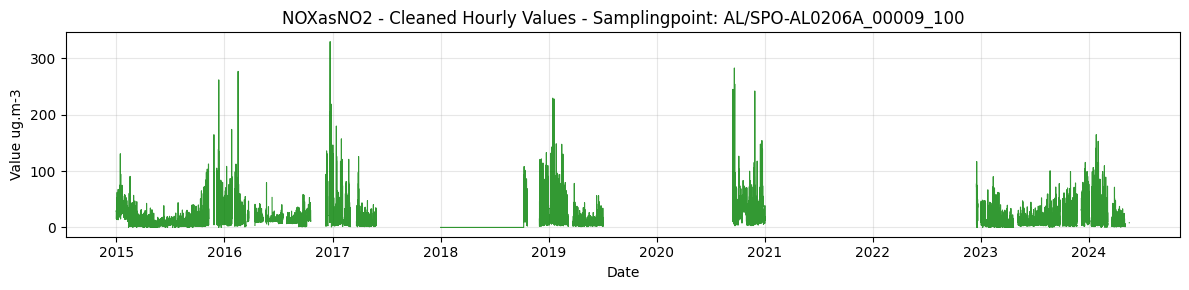

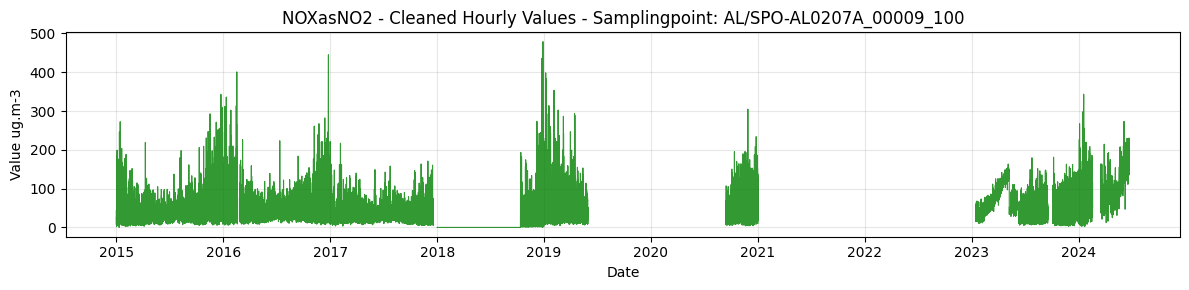

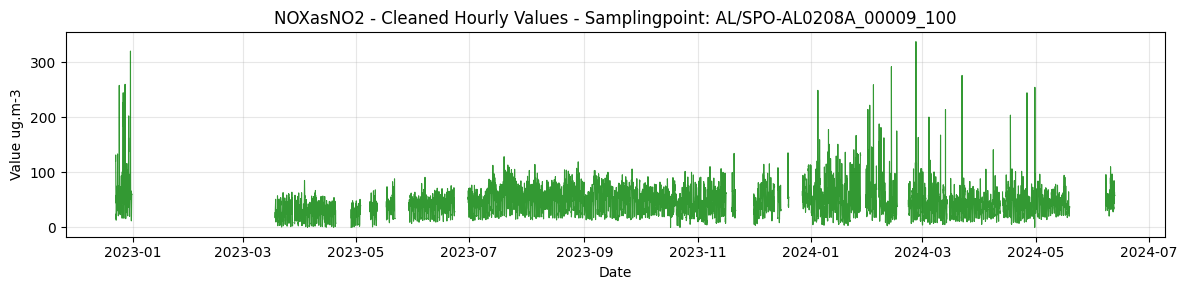

In [33]:
plot_dir = output_dir / "Cleaned_Hourly_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_hourly['Samplingpoint'].unique()

for station in stations:
    station_data = df_hourly[df_hourly['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='green', alpha=0.8, linewidth=0.8)
    plt.title(f'{POLLUTANT} - Cleaned Hourly Values - Samplingpoint: {station}')
    plt.ylabel('Value ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_cleaned_hourly.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.show()
    plt.close()

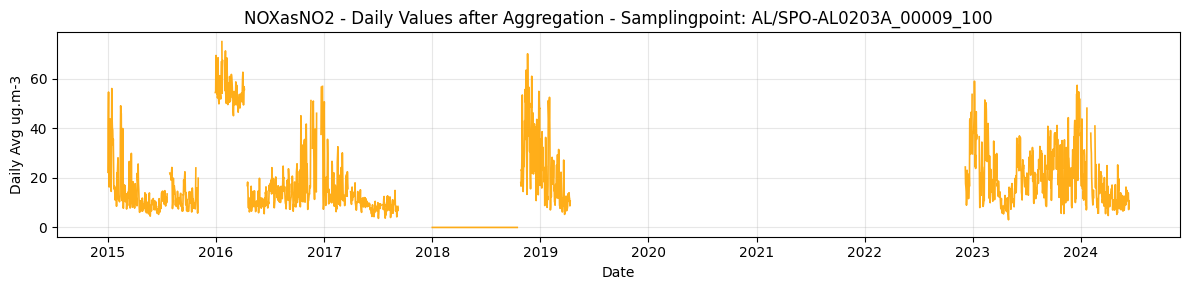

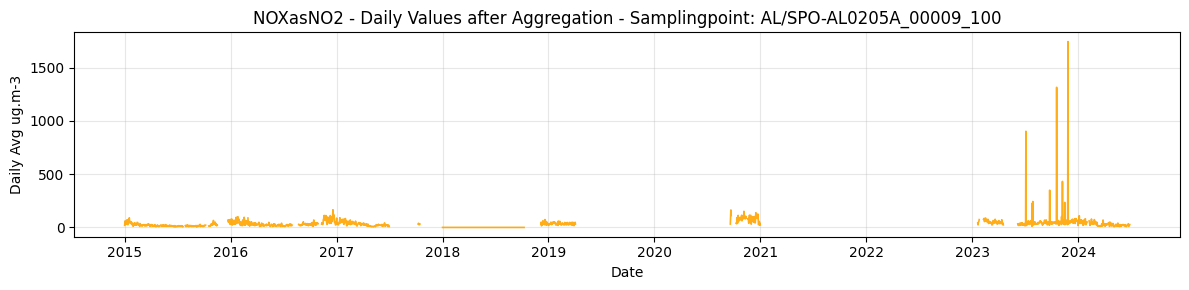

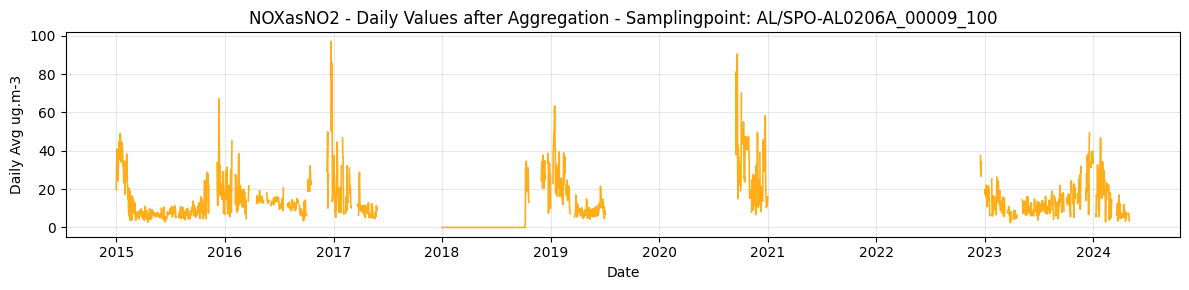

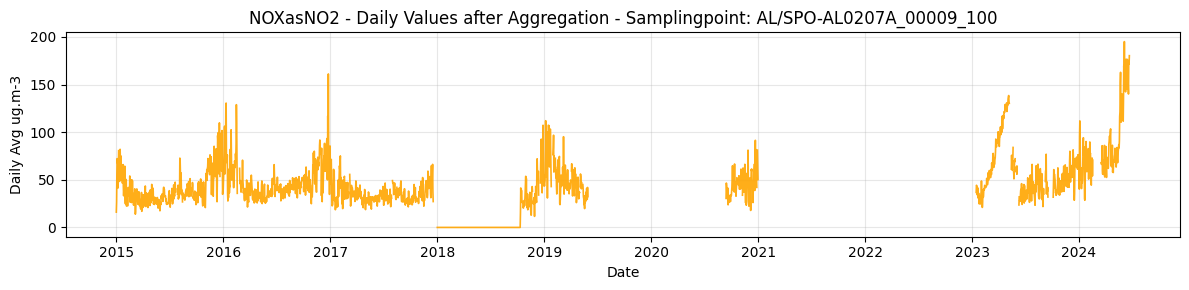

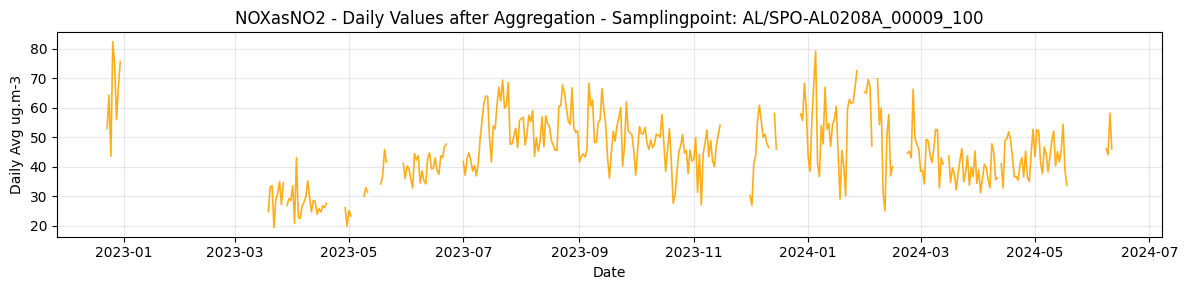

In [34]:
plot_dir = output_dir / "Daily_Aggregated_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_daily['Samplingpoint'].unique()

for station in stations:
    station_data = df_daily[df_daily['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='orange', alpha=0.9, linewidth=1.2)
    plt.title(f'{POLLUTANT} - Daily Values after Aggregation - Samplingpoint: {station}')
    plt.ylabel('Daily Avg ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_aggregated_daily.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.tight_layout()
    plt.show()
    plt.close()

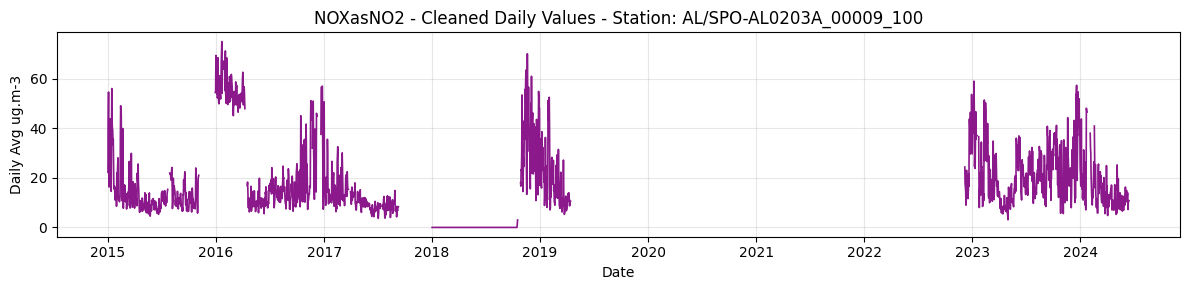

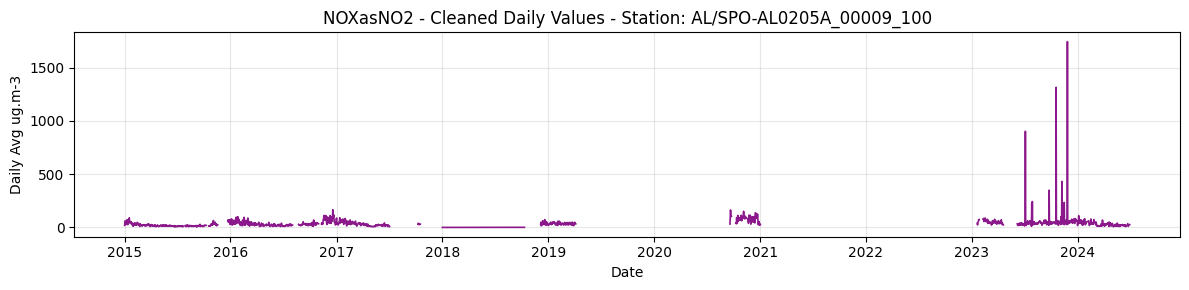

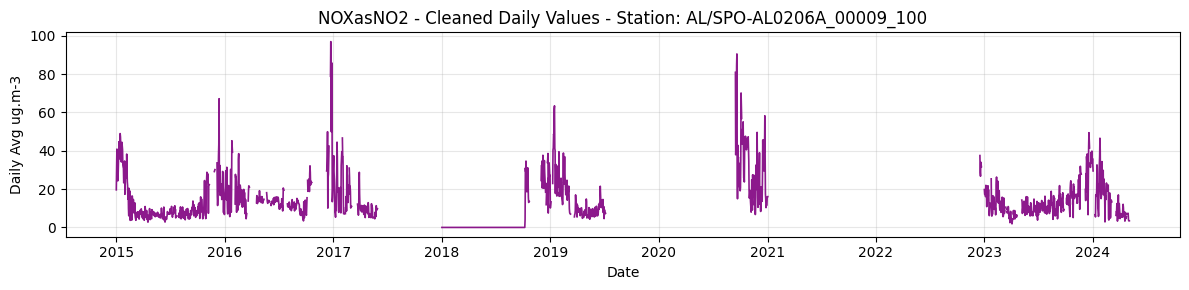

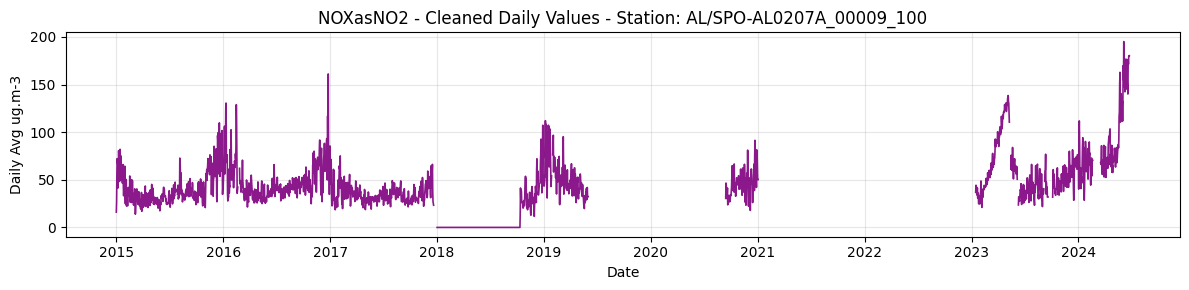

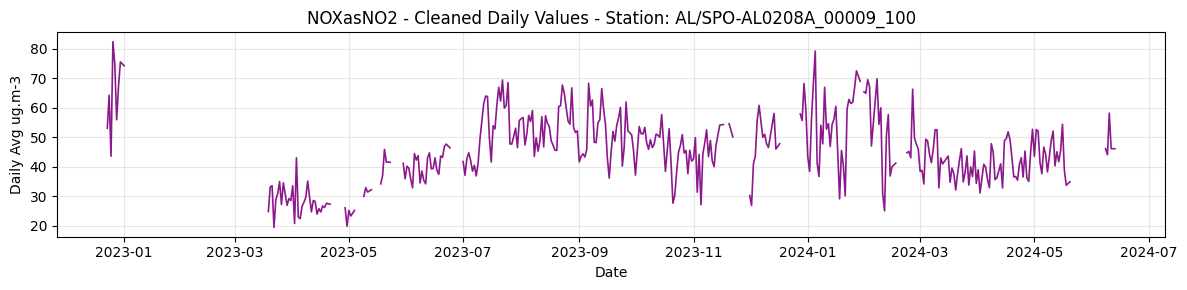

In [35]:
plot_dir = output_dir / "Cleaned_Daily_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_daily_Final['Samplingpoint'].unique()

for station in stations:
    station_data = df_daily_Final[df_daily_Final['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='purple', alpha=0.9, linewidth=1.2)
    plt.title(f'{POLLUTANT} - Cleaned Daily Values - Station: {station}')
    plt.ylabel('Daily Avg ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_cleanData_Daily.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.tight_layout()
    plt.show()
    plt.close()